<a href="https://colab.research.google.com/github/Suraram-Spandana/MDS_LABORATORY/blob/main/MDS_Week(6%2C7%2C8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

file_path = '/content/House-Price.csv'
try:
    house_df = pd.read_csv(file_path)
    print(f"Dataset '{file_path}' loaded successfully.")
    print("First 5 rows of the dataset:")
    display(house_df.head())
except FileNotFoundError:
    print(f"Error: '{file_path}' not found. Please ensure the file is uploaded to your Colab environment with the correct name and path.")
    house_df = None # Set house_df to None to indicate failure
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    house_df = None


Dataset '/content/House-Price.csv' loaded successfully.
First 5 rows of the dataset:


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,02-05-2014 0.00,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,02-05-2014 0.00,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,02-05-2014 0.00,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,02-05-2014 0.00,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,02-05-2014 0.00,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [13]:
# 1. Develop a model on residual analysis of simple linear regression.

# Check if house_df was loaded successfully
if 'house_df' in locals() and house_df is not None:
    X_column_name = 'sqft_living'
    Y_column_name = 'price'

    if X_column_name not in house_df.columns or Y_column_name not in house_df.columns:
        print(f"Error: Column '{X_column_name}' or '{Y_column_name}' not found in the dataset.")
        print("Available columns are:", house_df.columns.tolist())
    else:
        X = house_df[[X_column_name]]
        Y = house_df[Y_column_name]

        # Reshape X if it's a single feature, as sklearn expects 2D array
        X_reshaped = X.values.reshape(-1, 1)
        Y_array = Y.values

        # Create and Train the Linear Regression Model
        model = LinearRegression()
        model.fit(X_reshaped, Y_array)

        # Predict Y values and Calculate Residuals
        Y_pred = model.predict(X_reshaped)
        residuals = Y_array - Y_pred

        print("Simple Linear Regression Model Developed.")
        print("X (Feature) used:", X_column_name)
        print("Y (Target) used:", Y_column_name)
        print("\nResiduals (difference between actual and predicted) calculated.")

        # Store results in DataFrame for easier access in subsequent cells
        house_df['Y_predicted'] = Y_pred
        house_df['Residuals'] = residuals

else:
    print("Cannot develop model: house_df is not loaded or does not exist.")

Simple Linear Regression Model Developed.
X (Feature) used: sqft_living
Y (Target) used: price

Residuals (difference between actual and predicted) calculated.


In [14]:
import pandas as pd

# 4. Empirical model of linear regression analysis

# Ensure model, Y_column_name, X_column_name, and house_df are available
if 'model' in locals() and 'Y_column_name' in locals() and 'X_column_name' in locals() and 'house_df' in locals() and house_df is not None:
    # Regression Coefficient (Slope)
    coefficient = model.coef_[0]
    # Intercept
    intercept = model.intercept_

    print(f"Regression Coefficient (Slope for {X_column_name}): {coefficient:.4f}")
    print(f"Intercept: {intercept:.4f}")
    print(f"Regression Equation: {Y_column_name} = {intercept:.2f} + {coefficient:.2f} * {X_column_name}\n")

    print("--- Actual vs. Predicted vs. Residual ---")
    print(f"{Y_column_name} (Actual)\t\t{Y_column_name} (Predicted)\t\tResidual")
    print("--------------------------------------------------")

    # Display first few rows of actual, predicted, and residual values
    # Using house_df which already has 'Y_predicted' and 'Residuals'
    for index, row in house_df.head(20).iterrows():
        print(f"{row[Y_column_name]:.2f}\t\t\t{row['Y_predicted']:.2f}\t\t\t{row['Residuals']:.2f}")
    if len(house_df) > 20:
        print("<TRUNCATED>")

    # Optionally, you can also print the mean of residuals as a check
    print(f"\nMean of Residuals: {house_df['Residuals'].mean()}")

else:
    print("Model, column names, or house_df not found. Please run previous cells to develop the model and calculate predictions.")

Regression Coefficient (Slope for sqft_living): 251.9501
Intercept: 12954.2424
Regression Equation: price = 12954.24 + 251.95 * sqft_living

--- Actual vs. Predicted vs. Residual ---
price (Actual)		price (Predicted)		Residual
--------------------------------------------------
313000.00			350567.42			-37567.42
2384000.00			932572.22			1451427.78
342000.00			499218.00			-157218.00
420000.00			516854.50			-96854.50
550000.00			501737.50			48262.50
490000.00			234670.36			255329.64
335000.00			353086.92			-18086.92
482000.00			695739.10			-213739.10
452500.00			625193.06			-172693.06
640000.00			395918.44			244081.56
463000.00			443788.97			19211.03
1400000.00			748648.63			651351.37
588500.00			599998.05			-11498.05
365000.00			287579.89			77420.11
1200000.00			746129.12			453870.88
242500.00			315294.40			-72794.40
419000.00			408515.95			10484.05
367500.00			796519.15			-429019.15
257950.00			358125.92			-100175.92
275000.00			310255.40			-35255.40
<TRUNCATED>

Mean of Residuals: 4.413

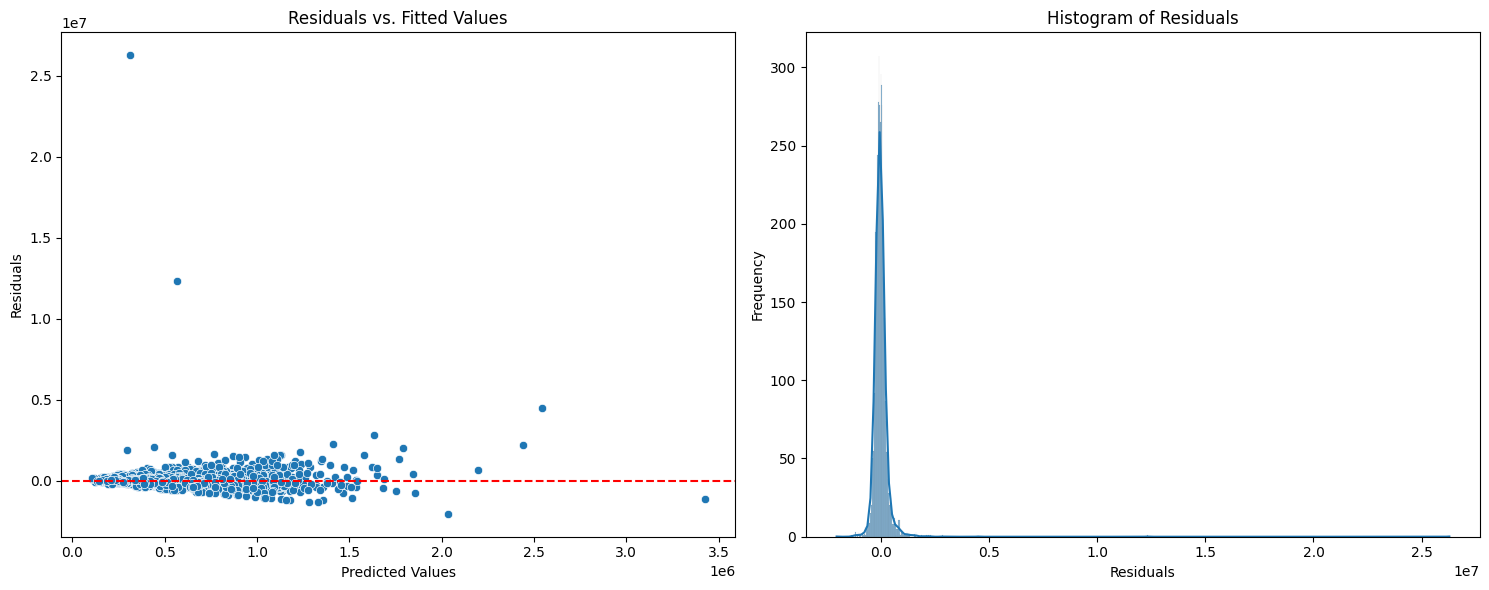

In [12]:
# 2. Residual plots of linear regression

# Ensure model, Y_pred, and residuals exist from previous cell
if 'model' in locals() and 'Y_pred' in locals() and 'residuals' in locals():
    plt.figure(figsize=(15, 6))

    # Plot 1: Residuals vs. Fitted Values
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=Y_pred, y=residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs. Fitted Values")

    # Plot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    sns.histplot(residuals, kde=True)
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title("Histogram of Residuals")

    plt.tight_layout()
    plt.show()
else:
    print("Model, predictions, or residuals not found. Please run the previous cell to develop the model.")

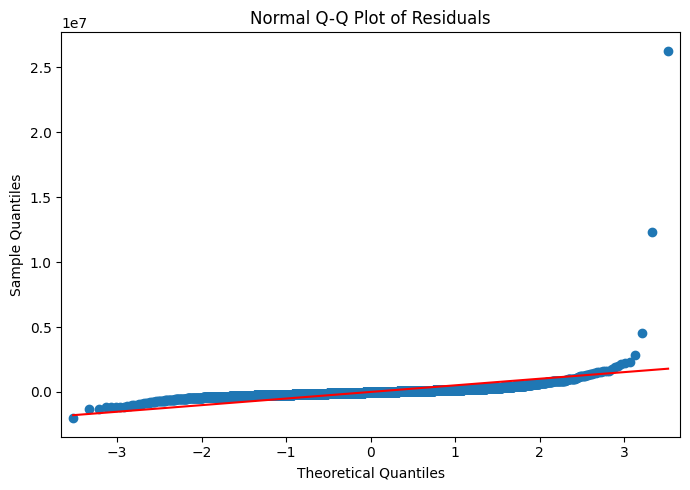

In [6]:
# 3. Normal probability plots (Q-Q Plot)

# Ensure residuals are available from previous cell
if 'residuals' in locals():
    plt.figure(figsize=(7, 5))
    sm.qqplot(residuals, line='s', ax=plt.gca())
    plt.title("Normal Q-Q Plot of Residuals")
    plt.tight_layout()
    plt.show()
else:
    print("Residuals not found. Please run the cell that develops the model and calculates residuals.")

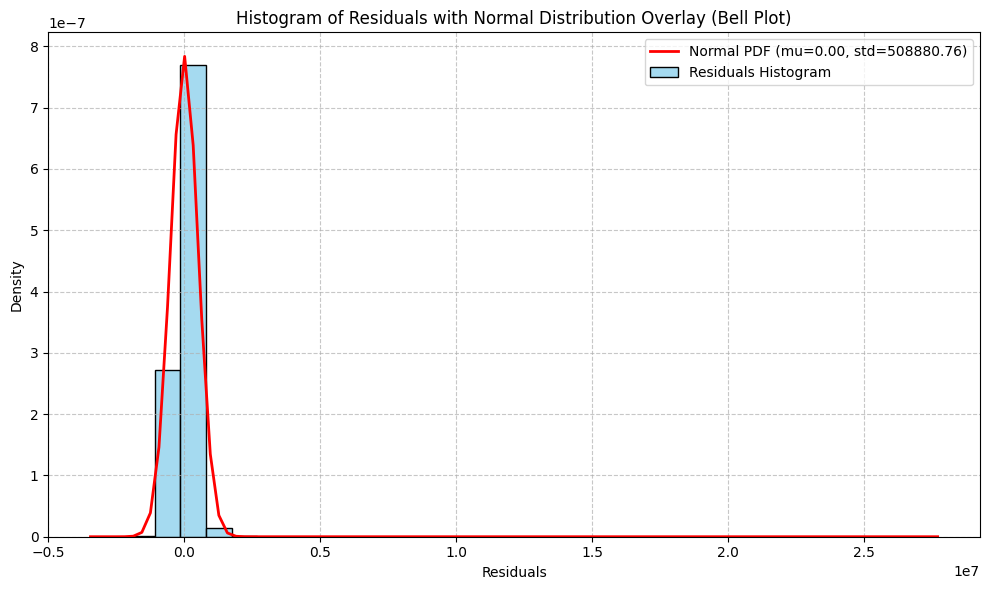

In [15]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Normal Probability Plot (Bell Plot - Histogram with Normal Curve)

# Ensure residuals are available from previous cell
if 'residuals' in locals():
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, bins=30, kde=False, color='skyblue', stat='density', label='Residuals Histogram')

    # Overlay a normal distribution curve
    mu, std = norm.fit(residuals)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'r', linewidth=2, label=f'Normal PDF (mu={mu:.2f}, std={std:.2f})')

    plt.title('Histogram of Residuals with Normal Distribution Overlay (Bell Plot)')
    plt.xlabel('Residuals')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Residuals not found. Please run the cell that develops the model and calculates residuals.")

Generating Normal Probability Plots for all numerical columns...


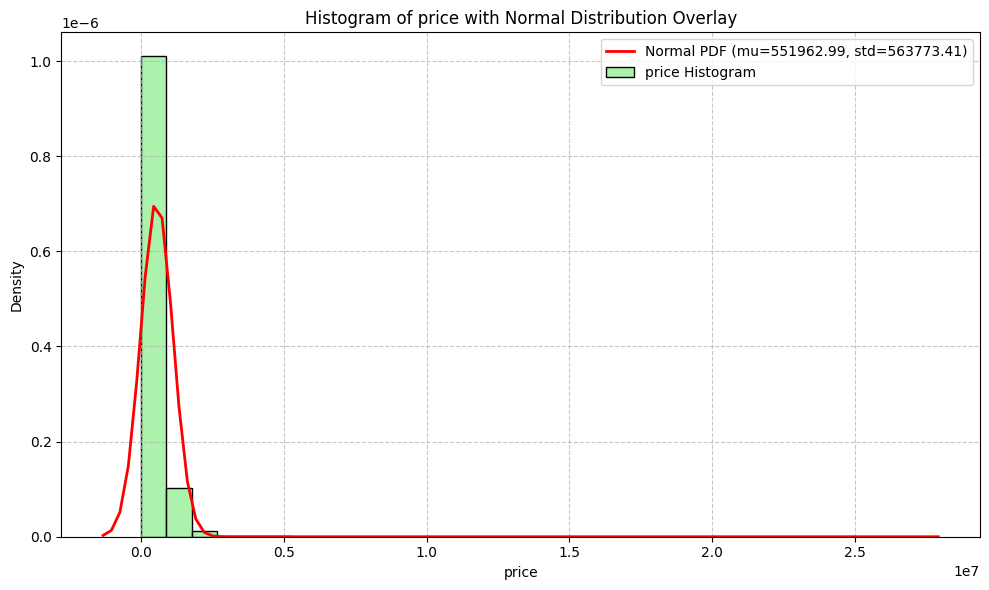

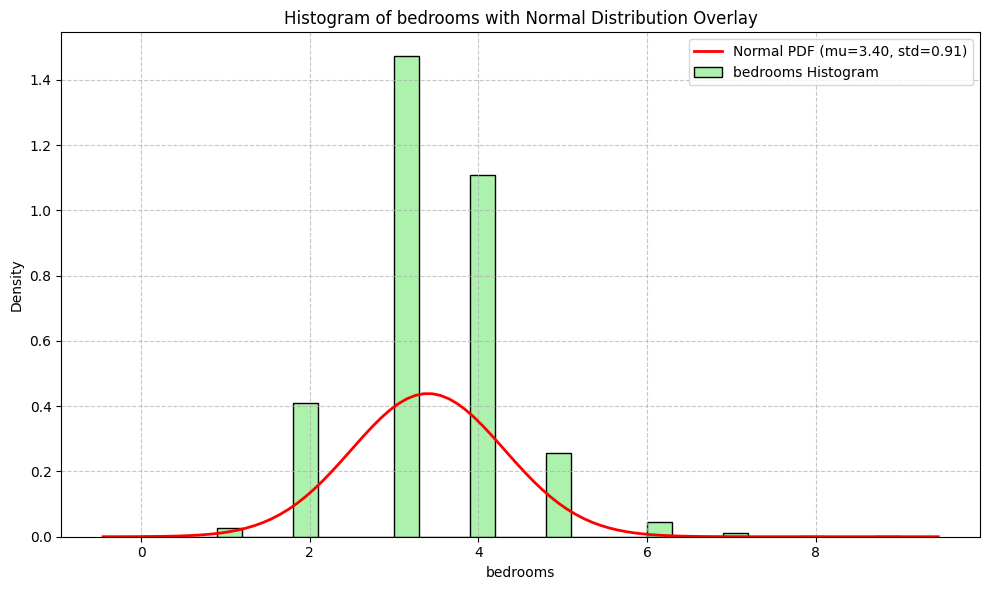

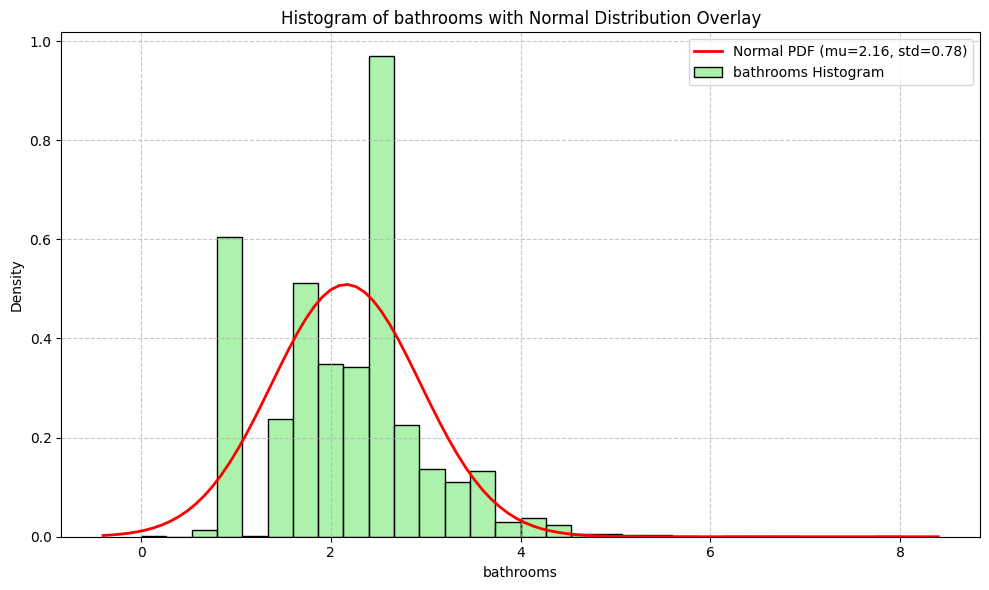

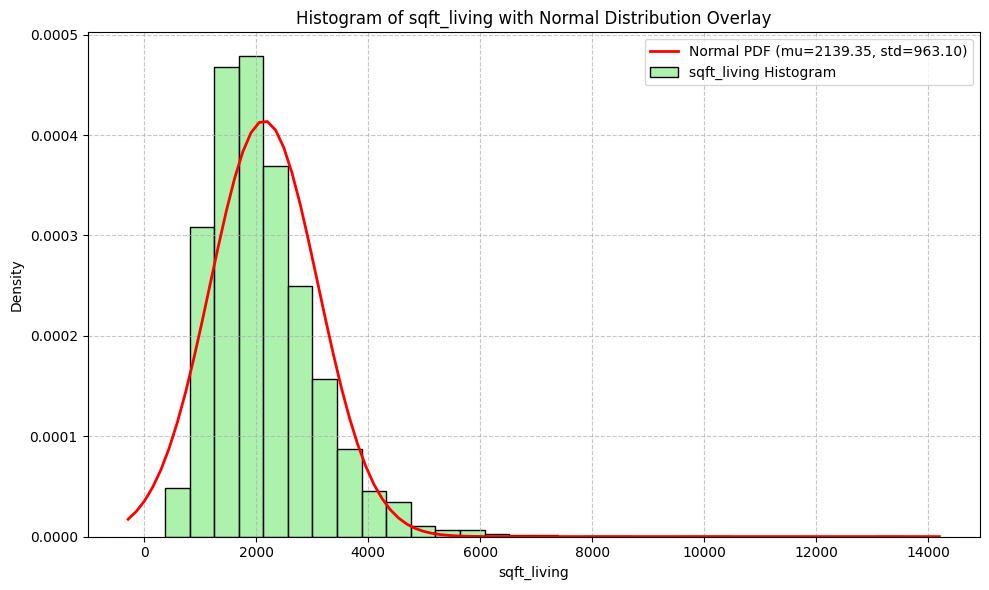

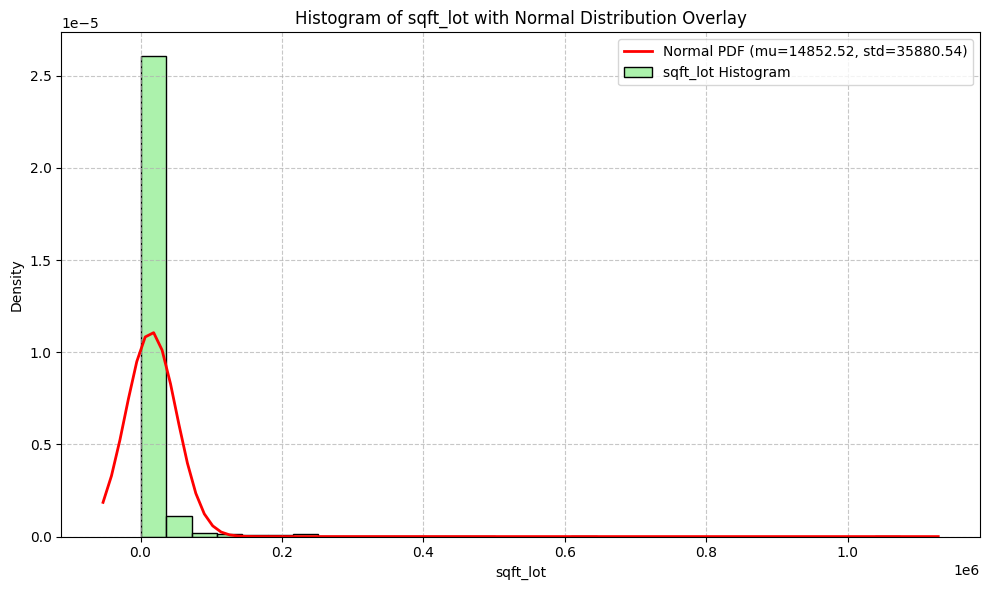

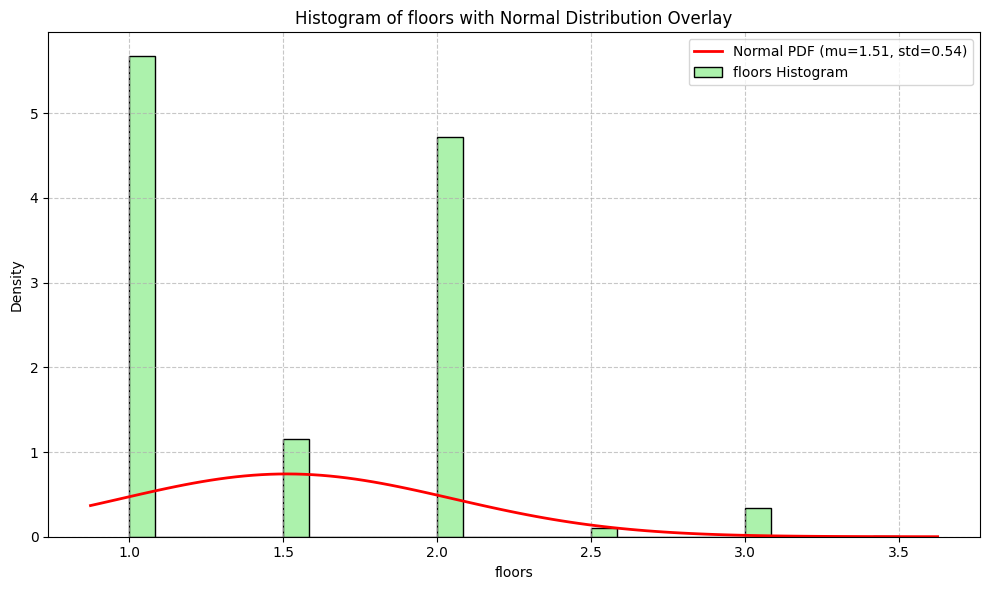

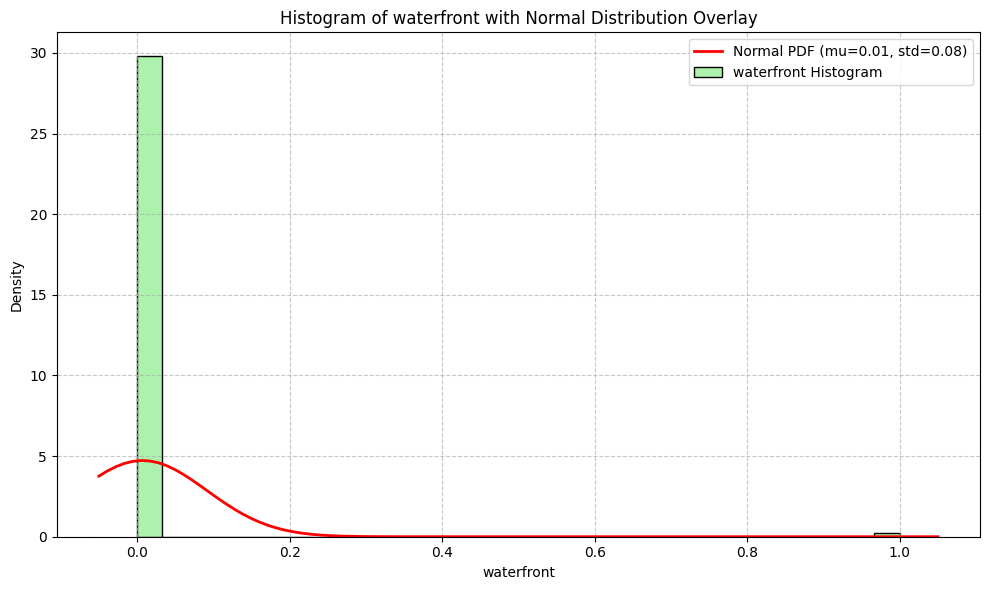

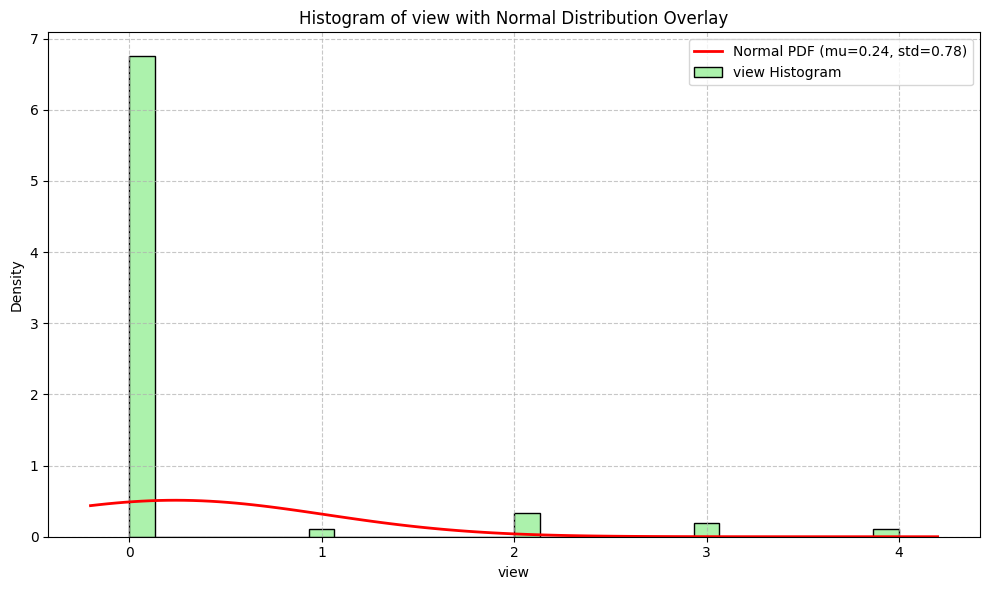

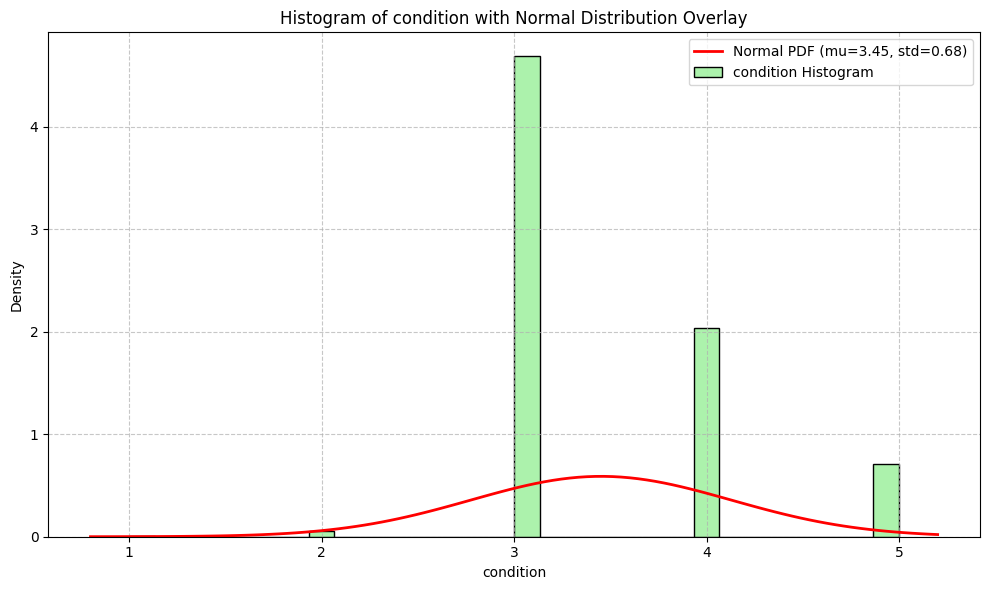

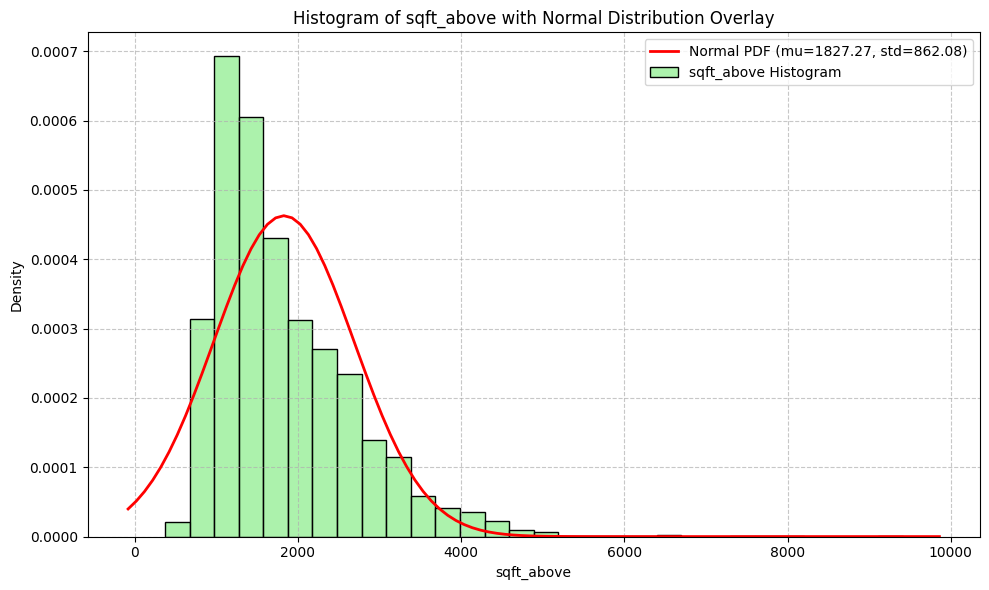

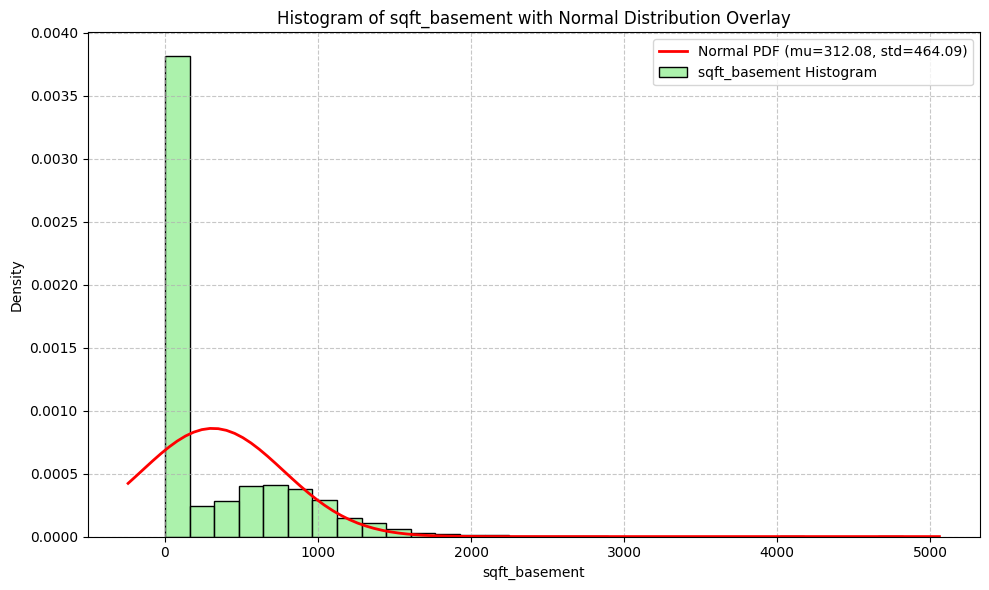

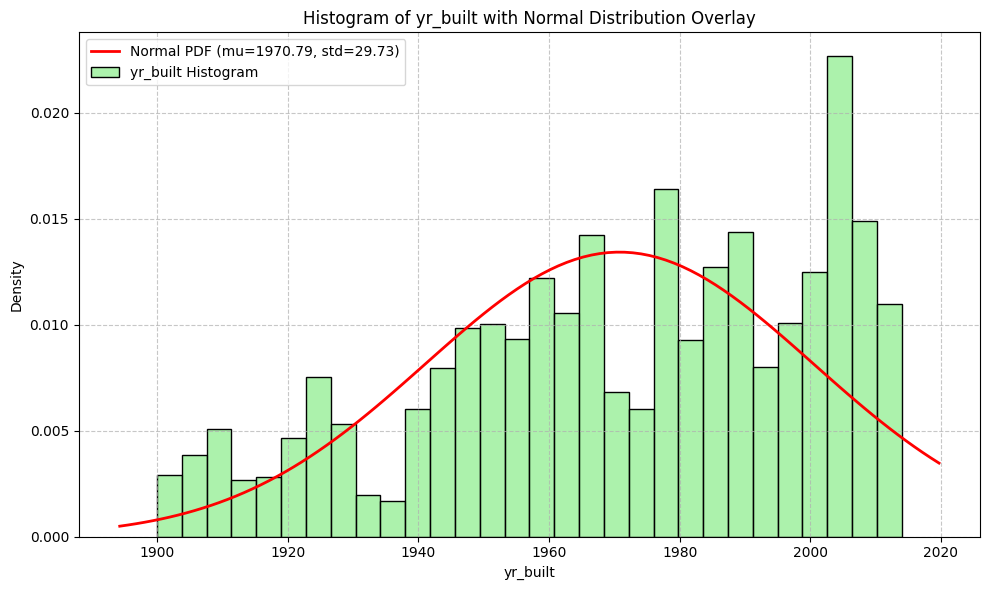

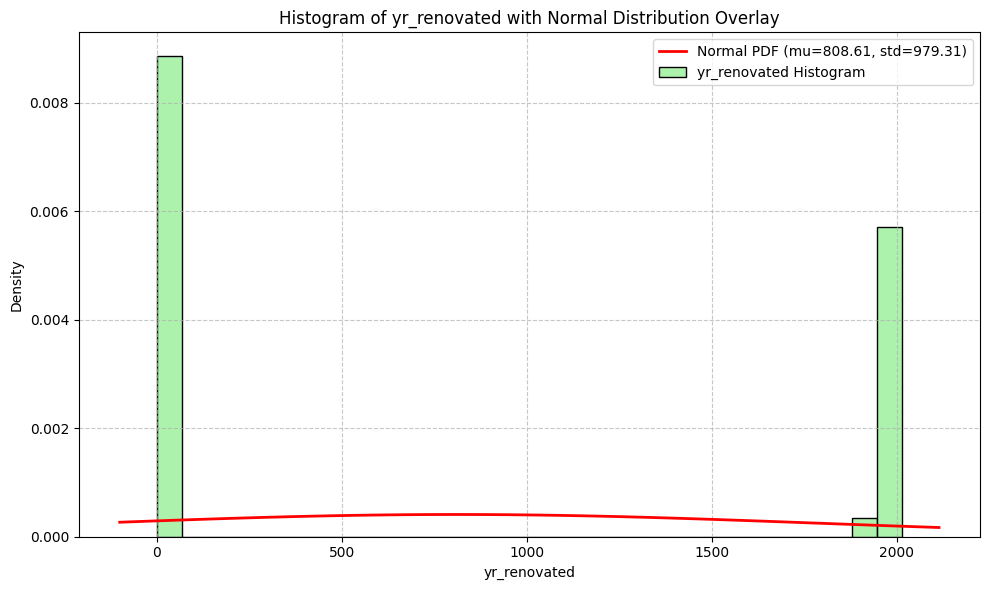

In [16]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for np.number and np.linspace

# 6. Normal Probability Plots (Bell Plot - Histogram with Normal Curve) for all numerical columns

if 'house_df' in locals() and house_df is not None:
    # Select only numerical columns for plotting
    numerical_cols = house_df.select_dtypes(include=np.number).columns.tolist()

    # Exclude Y_predicted and Residuals if they were added in previous steps and not desired here
    if 'Y_predicted' in numerical_cols: numerical_cols.remove('Y_predicted')
    if 'Residuals' in numerical_cols: numerical_cols.remove('Residuals')

    print("Generating Normal Probability Plots for all numerical columns...")
    for col in numerical_cols:
        # Drop NaN values for accurate distribution fitting
        col_data = house_df[col].dropna()

        if not col_data.empty:
            plt.figure(figsize=(10, 6))
            sns.histplot(col_data, bins=30, kde=False, color='lightgreen', stat='density', label=f'{col} Histogram')

            # Overlay a normal distribution curve
            mu, std = norm.fit(col_data)
            xmin, xmax = plt.xlim()
            x = np.linspace(xmin, xmax, 100)
            p = norm.pdf(x, mu, std)
            plt.plot(x, p, 'r', linewidth=2, label=f'Normal PDF (mu={mu:.2f}, std={std:.2f})')

            plt.title(f'Histogram of {col} with Normal Distribution Overlay')
            plt.xlabel(col)
            plt.ylabel('Density')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
        else:
            print(f"Skipping column '{col}' as it contains no numerical data after dropping NaNs.")
else:
    print("house_df not found. Please load the dataset in previous cells.")